# Laboratorio 1: Regresión Lineal Multivariable
**Estudiante:** [Tu Nombre]  
**Dataset:** energy_dataset.csv

En este laboratorio se implementa un modelo de regresión lineal multivariable para predecir el **precio real de energía** usando variables de generación y demanda.

In [1]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot

## 1. Carga y Preprocesamiento de Datos

Se utiliza **Pandas** para cargar `energy_dataset.csv` y seleccionar columnas numéricas relevantes para predecir `price actual`.

In [2]:
dataset_path = 'energy_dataset.csv'

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f'No se encontró el dataset en: {dataset_path}')

df = pd.read_csv(dataset_path)

columns = [
    'generation fossil gas',
    'generation fossil hard coal',
    'generation fossil oil',
    'generation hydro pumped storage consumption',
    'generation hydro run-of-river and poundage',
    'generation hydro water reservoir',
    'generation nuclear',
    'generation other renewable',
    'generation solar',
    'generation wind onshore',
    'total load forecast',
    'total load actual',
    'price day ahead',
    'price actual'
]

df = df[columns].dropna()

print(f'Dataset cargado con {df.shape[0]} filas y {df.shape[1]} columnas.')

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
m = y.size

print(f'número de propiedades (n): {X.shape[1]}')
print(f'número de ejemplos (m): {m}')

Dataset cargado con 35020 filas y 14 columnas.
número de propiedades (n): 13
número de ejemplos (m): 35020


## 1.1 Normalización de Características

Es fundamental para que el descenso por gradiente converja eficientemente.

In [4]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)

# Añadimos la columna de unos para el término de intercepción (theta_0)
X_norm = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

## 2. Regresión Lineal
### 2.1 Función de Costo

In [5]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    h = np.dot(X, theta)
    J = (1 / (2 * m)) * np.sum(np.square(h - y))
    return J

### 2.2 Descenso por Gradiente

In [7]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    J_history = []

    for i in range(num_iters):
        h = np.dot(X, theta)
        theta = theta - (alpha / m) * np.dot(X.T, (h - y))
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

## 3. Entrenamiento

Se entrena el modelo con los hiperparámetros definidos por el ingeniero: `alpha = 0.01` y `num_iters = 1000`.

Mejor alpha: 0.1
Mejor num_iters: 4000
Costo final mínimo: 43.265226628476924


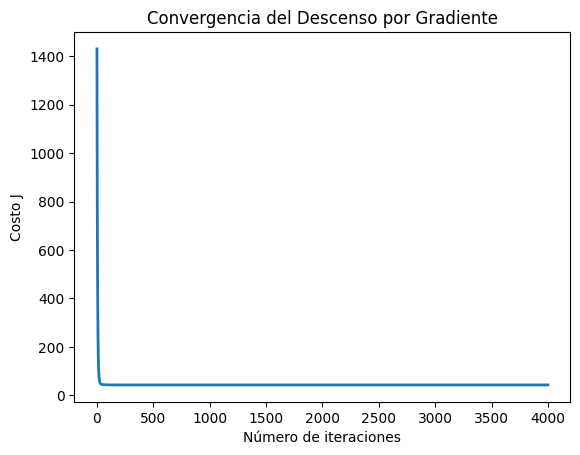

In [ ]:
alpha = 0.01
num_iters = 1000

theta = np.zeros(X_norm.shape[1])
theta, J_history = gradientDescentMulti(X_norm, y, theta, alpha, num_iters)

# Graficar la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Descenso por Gradiente')
print(f"Costo final: {J_history[-1]}")

## 4. Inferencia

Probamos el modelo con un ejemplo (promedio de los datos).

In [9]:
# Ejemplo de inferencia con valores promedio
sample_data = np.mean(X, axis=0)
sample_norm = (sample_data - mu) / sigma
sample_norm = np.append(1, sample_norm)  # Agregar bias

prediction = np.dot(sample_norm, theta)
print(f'Predicción de precio para valores promedio: {prediction:.2f}')
print(f'Precio real promedio: {np.mean(y):.2f}')

Predicción de precio para valores promedio: 57.88
Precio real promedio: 57.89
